# 13 Clustering and Anomaly Detection

This copy notebook keeps the unsupervised stage aligned with the course workflow.

Allowed methods used here:
- KMeans
- Agglomerative clustering
- DBSCAN
- Gaussian Mixture Models
- Isolation Forest
- Local Outlier Factor

The unit of analysis is the flood event. Clusters are exploratory archetypes, and anomaly flags are diagnostics rather than data-cleaning rules.

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from IPython.display import display

ROOT = Path.cwd()
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [11]:
from project_name.modeling_stage import (
    ANOMALY_SCORES_PATH,
    CLUSTERING_ARCHETYPES_GEOPARQUET_PATH,
    CLUSTERING_ARCHETYPES_PATH,
    CLUSTERING_MODEL_SELECTION_PATH,
    clustering_feature_sets,
    evaluate_clustering_algorithms,
    feature_catalog,
    load_modeling_frame,
    pca_embedding,
    summarize_feature_groups,
    unavailable_expected_features,
)

observed = load_modeling_frame(view_name="strict_main", include_geometry=False, observed_only=True)
print(f"observed flood events: {len(observed):,}")
print(f"unique segments: {observed['segment_id'].nunique():,}")
display(summarize_feature_groups(observed))
display(unavailable_expected_features(observed))
display(feature_catalog(observed).head(40))

observed flood events: 34,870
unique segments: 17,053


,feature_group,expected_features,available_features,mean_non_null_rate,missing_features
0,event_time,8,8,0.998824,0
1,extra,18,18,0.999471,0
2,governance,3,3,1.000000,0
3,hydrometeorology,6,6,0.987104,0
4,infrastructure,4,4,0.500000,0
5,network,9,9,0.444444,0
6,socioeconomic,4,4,0.983589,0
7,spatial_controls,5,5,1.000000,0
8,targets,4,4,0.997648,0
9,terrain_coastal,8,8,0.999986,0


,feature_group,feature,available,dtype,non_null_rate,n_unique


,feature_group,feature,available,dtype,non_null_rate,n_unique
0,event_time,day_of_week,True,Int64,1.000000,7
1,event_time,duration,True,float64,1.000000,7452
2,event_time,end,True,datetime64[us],0.990594,31625
3,event_time,hour,True,Int64,1.000000,24
4,event_time,month,True,Int64,1.000000,12
5,event_time,season,True,string,1.000000,4
6,event_time,start,True,datetime64[us],1.000000,32123
7,event_time,storm_event_id,True,string,1.000000,117
8,extra,catch_basin_nearest_ft,True,float64,1.000000,16985
9,extra,component_size,True,int64,1.000000,52


In [12]:
selection_df, archetypes, anomalies = evaluate_clustering_algorithms(observed)

display(
    selection_df.sort_values(
        ["feature_set", "silhouette_score", "calinski_harabasz_score"],
        ascending=[True, False, False],
        kind="stable",
    ).groupby("feature_set", as_index=False).head(8)
)
display(archetypes.head())
display(anomalies.head())

print(f"saved: {CLUSTERING_MODEL_SELECTION_PATH}")
print(f"saved: {CLUSTERING_ARCHETYPES_PATH}")
print(f"saved: {ANOMALY_SCORES_PATH}")

,feature_set,algorithm,k,n_clusters,noise_fraction,silhouette_score,calinski_harabasz_score,davies_bouldin_score,aic,bic,sample_n,eps,min_samples
120,combined,dbscan,NaN,3,0.996333,0.865645,764.429140,0.186354,NaN,NaN,12000,0.5,10.0
94,combined,agglomerative,2.0,2,0.000000,0.387844,932.393851,1.509302,NaN,NaN,12000,NaN,NaN
97,combined,agglomerative,3.0,3,0.000000,0.338285,915.648409,1.134739,NaN,NaN,12000,NaN,NaN
93,combined,kmeans,2.0,2,0.000000,0.250726,1205.742031,2.258923,NaN,NaN,12000,NaN,NaN
121,combined,dbscan,NaN,25,0.872833,0.212685,160.869907,1.126012,NaN,NaN,12000,1.0,10.0
117,combined,kmeans,10.0,10,0.000000,0.127194,1025.971385,1.568194,NaN,NaN,12000,NaN,NaN
114,combined,kmeans,9.0,9,0.000000,0.126129,1040.002396,1.611828,NaN,NaN,12000,NaN,NaN
111,combined,kmeans,8.0,8,0.000000,0.124106,1051.333279,1.722980,NaN,NaN,12000,NaN,NaN
35,infrastructure_network,agglomerative,3.0,3,0.000000,0.678157,3049.858041,0.621908,NaN,NaN,12000,NaN,NaN
32,infrastructure_network,agglomerative,2.0,2,0.000000,0.672545,2472.546241,0.689976,NaN,NaN,12000,NaN,NaN


,event_id,segment_id,analysis_view_name,dataset_split_role,label_definition,possible_unreported_flood,occurrence,intensity,resolution,resolution_bool,start,end,duration,month,season,hour,day_of_week,storm_event_id,n_prec,prec_intensity_max,prec_intensity_mean,prec_depth_total,prec_duration_total,max_tide,elevation,slope,shore_dist,fema_fld_zone,road_class,edge_betweenness,component_count_after_removal,giant_component_size_after_removal,giant_component_size_loss,additional_disconnected_node_pairs,pct_giant_component_loss,high_network_criticality,drainage_catch_basin_nearest_ft,outfall_nearest_ft,pump_nearest_ft,critical_infra_exposure,census_poverty_rate,census_renter_share,census_no_vehicle_share,census_median_household_income,gov_city,borough,present_occurrence,present_intensity,present_resolution,present_resolution_bool,present_start,present_end,present_duration,present_month,present_season,present_hour,present_day_of_week,present_storm_event_id,present_n_prec,present_prec_intensity_max,present_prec_intensity_mean,present_prec_depth_total,present_prec_duration_total,present_max_tide,present_elevation,present_slope,present_shore_dist,present_fema_fld_zone,present_road_class,present_edge_betweenness,present_component_count_after_removal,present_giant_component_size_after_removal,present_giant_component_size_loss,present_additional_disconnected_node_pairs,present_pct_giant_component_loss,present_high_network_criticality,present_drainage_catch_basin_nearest_ft,present_outfall_nearest_ft,present_pump_nearest_ft,present_critical_infra_exposure,present_census_poverty_rate,present_census_renter_share,present_census_no_vehicle_share,present_census_median_household_income,present_gov_city,present_borough,has_all_selected_fields,event_start_local,event_end_local,event_window_end_local,event_window_duration_hours,event_month,precip_polygon_id,tide_polygon_id,station_p_id,tide_id,segment_borough,segment_travel_time_s,segment_edge_betweenness,component_size,shore_graph_steps,shore_dist_ft,dem_mean,dem_slope,fema_zone_subty,fema_overlap_ft,fema_overlap_share,fema_sfha_any,catch_basin_nearest_ft,travel_time,tide_polygon,tide_station,precipitation_polygon,precipitation_station,gov_borough,mayoral_administration,physical_forcing_cluster_id,infrastructure_network_cluster_id,social_governance_cluster_id,combined_cluster_id,cluster_label
0,1,100001,strict_main,positive,observed_reported_flood,False,True,1,14.116667,True,2023-11-21 10:38:00,2023-11-22 10:45:00,14.116667,11,SON,10,1,STORM_00080,1,3.288066,3.288066,52.609055,16.0,3.094939,20.910007,0.015283,13601.722949,X,local,2859835.0,<NA>,<NA>,<NA>,<NA>,<NA>,False,13.500714,3565.874864,<NA>,<NA>,0.195868,0.242574,0.087459,108053.0,NEW YORK CITY,QUEENS,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False,False,True,True,True,False,False,True,True,True,True,True,True,False,2023-11-21 10:38:00,2023-11-22 10:45:00,2023-11-22 00:45:00,14.116667,11,USW00094789,8516945,USW00094789,8516945,QUEENS,19.086073,2859835.0,102370,189.000000,13601.722949,20.910007,0.015283,AREA OF MINIMAL FLOOD HAZARD,699.822694,1.000000,False,13.500714,19.086073,8516945,8516945,USW00094789,USW00094789,QUEENS,eric_adams_2022_2025,3,1,0,0,mixed-archetype-0
1,10,100097,strict_main,positive,observed_reported_flood,False,True,2,8.985833,True,2023-09-28 22:50:51,2023-09-29 15:50:00,8.985833,9,SON,22,3,STORM_00073,1,9.040300,9.040300,216.967200,24.0,3.038856,35.035000,0.011381,6764.919820,X,local,87399.0,<NA>,<NA>,<NA>,<NA>,<NA>,False,33.860541,2913.973818,<NA>,<NA>,0.058102,0.330181,0.111020,95803.0,NEW YORK CITY,QUEENS,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False,False,True,True,True,False,False,True,True,True,True,True,True,False,2023-09-28 22:50:51,2023-09-29 15:50:00,2023-09-29 07:50:00,8.985833,9,USW00014732,8516945,USW00014732,8516945,QUEE

,event_id,segment_id,occurrence,intensity,resolution,resolution_bool,anomaly_score_isolation_forest,anomaly_flag_isolation_forest,anomaly_score_lof,anomaly_flag_lof,anomaly_flag_dbscan_noise,anomaly_score_robust_z,anomaly_flag_robust_z,anomaly_method_agreement,anomaly_score,anomaly_flag
0,6539,159391,True,2,360.966667,True,0.662414,True,2.295571,True,True,1859.751296,True,4,0.998910,True
1,30736,81247,True,1,5.783333,True,0.644167,True,1.781701,True,True,1875.284301,True,4,0.998308,True
2,20420,41761,True,1,38.883333,True,0.597092,True,4.429282,True,True,1858.631711,True,4,0.998212,True
3,13845,275873,True,1,234.066667,True,0.628988,True,2.307927,True,True,1852.552326,True,4,0.998117,True
4,8866,175382,True,1,410.483333,True,0.622124,True,2.113691,True,True,1855.726518,True,4,0.998117,True


saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/clustering_model_selection.csv
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/clustering_event_archetypes.parquet
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/anomaly_event_scores.parquet


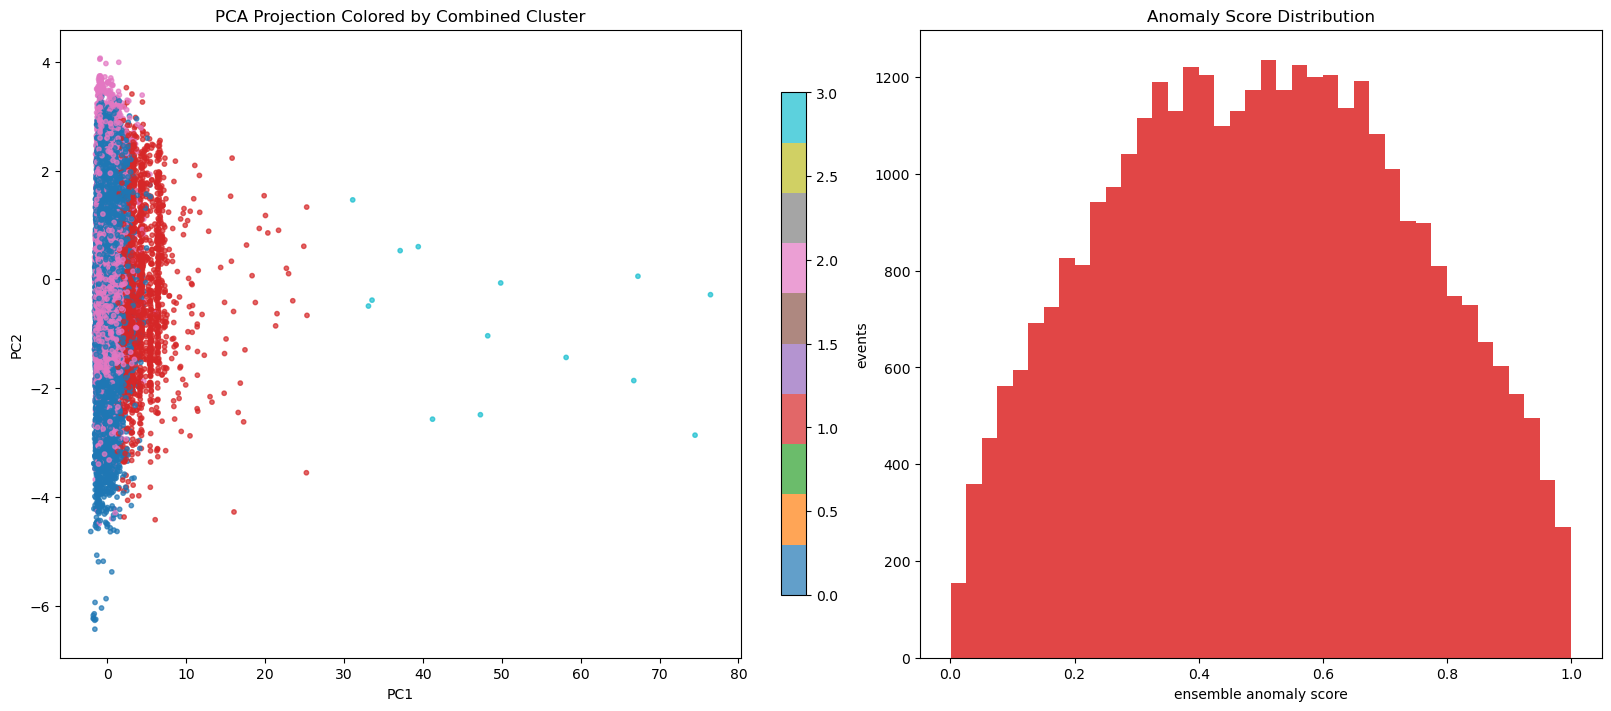

In [13]:
combined_features = clustering_feature_sets(observed)["combined"]
pca_points = pca_embedding(observed, combined_features)
pca_plot = pca_points.merge(
    archetypes[["event_id", "combined_cluster_id", "cluster_label", "intensity", "resolution"]],
    on="event_id",
    how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
scatter = axes[0].scatter(
    pca_plot["pc1"],
    pca_plot["pc2"],
    c=pd.to_numeric(pca_plot["combined_cluster_id"], errors="coerce"),
    cmap="tab10",
    s=10,
    alpha=0.7,
)
axes[0].set_title("PCA Projection Colored by Combined Cluster")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(scatter, ax=axes[0], shrink=0.8)

axes[1].hist(pd.to_numeric(anomalies["anomaly_score"], errors="coerce").dropna(), bins=40, color="#DC2626", alpha=0.85)
axes[1].set_title("Anomaly Score Distribution")
axes[1].set_xlabel("ensemble anomaly score")
axes[1].set_ylabel("events")
plt.show()

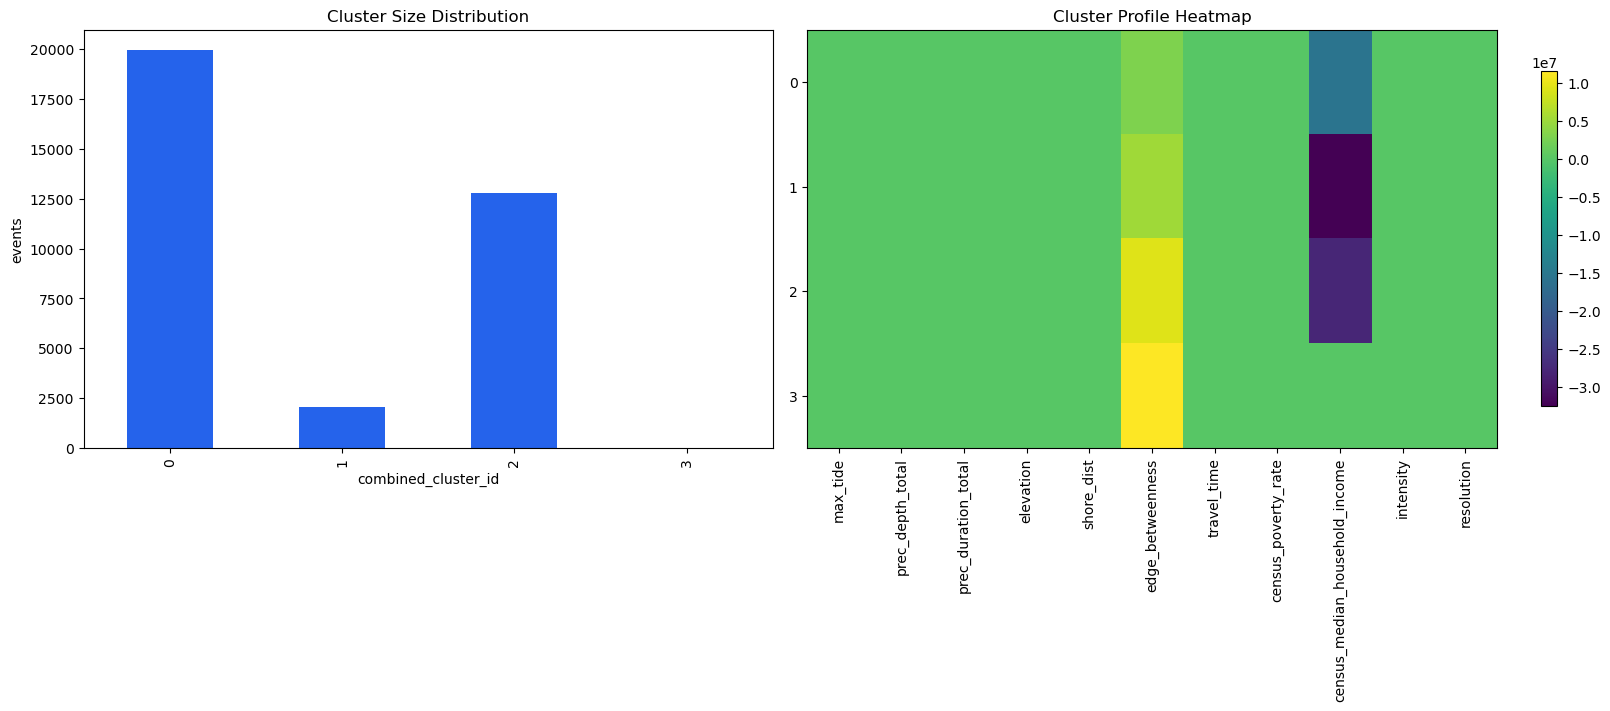

,max_tide,prec_depth_total,prec_duration_total,elevation,shore_dist,edge_betweenness,travel_time,census_poverty_rate,census_median_household_income,intensity,resolution
combined_cluster_id,,,,,,,,,,,
0,1.839102,30.881342,9.105874,13.563104,5624.923331,2.919369e+06,12.194439,0.089837,-1.559323e+07,1.078621,33.834179
1,1.968704,281.826873,23.499637,12.917175,5454.961056,5.199052e+06,11.656290,0.143034,-3.254124e+07,1.360465,157.345362
2,1.653673,30.488110,8.102182,12.084763,5383.037748,9.223865e+06,11.085893,0.236414,-2.773570e+07,1.073927,27.351735
3,2.699178,1491.193907,572.905952,12.990274,8545.144782,1.144957e+07,12.649990,0.143598,6.712500e+04,3.571429,6831.166667


,combined_cluster_id,cluster_label,n_events,mean_intensity,mean_resolution_hours
0,0,mixed-archetype-0,19982,1.078621,33.834179
1,1,mixed-archetype-1,2064,1.360465,157.345362
2,2,low-elevation FEMA-exposed / shore-proximate,12810,1.073927,27.351735
3,3,coastal-tide dominated / heavy-precipitation p...,14,3.571429,6831.166667


In [14]:
profile_cols = [
    column
    for column in [
        "max_tide",
        "prec_depth_total",
        "prec_duration_total",
        "elevation",
        "shore_dist",
        "edge_betweenness",
        "travel_time",
        "census_poverty_rate",
        "census_median_household_income",
        "intensity",
        "resolution",
    ]
    if column in archetypes.columns
]
cluster_profiles = archetypes.groupby("combined_cluster_id")[profile_cols].mean(numeric_only=True)
cluster_counts = archetypes["combined_cluster_id"].value_counts(dropna=False).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
cluster_counts.plot.bar(ax=axes[0], color="#2563EB")
axes[0].set_title("Cluster Size Distribution")
axes[0].set_xlabel("combined_cluster_id")
axes[0].set_ylabel("events")

im = axes[1].imshow(cluster_profiles.to_numpy(dtype=float), aspect="auto", cmap="viridis")
axes[1].set_title("Cluster Profile Heatmap")
axes[1].set_xticks(range(len(cluster_profiles.columns)))
axes[1].set_xticklabels(cluster_profiles.columns, rotation=90)
axes[1].set_yticks(range(len(cluster_profiles.index)))
axes[1].set_yticklabels(cluster_profiles.index.astype(str))
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.show()

display(cluster_profiles)
display(
    archetypes.groupby(["combined_cluster_id", "cluster_label"], as_index=False)
    .agg(
        n_events=("event_id", "size"),
        mean_intensity=("intensity", "mean"),
        mean_resolution_hours=("resolution", "mean"),
    )
)

In [15]:
try:
    geo = gpd.read_parquet(CLUSTERING_ARCHETYPES_GEOPARQUET_PATH).to_crs(2263)
    top_anomalies = anomalies.head(250)[["event_id"]].merge(geo, on="event_id", how="left")

    fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)
    # set_axis_off() before plot: constrained_layout uses AutoDateLocator on the
    # state-plane coordinates (~900 000 ft), which overflows matplotlib's date ordinal.
    axes[0].set_axis_off()
    axes[1].set_axis_off()

    geo.plot(ax=axes[0], column="combined_cluster_id", categorical=True, legend=True, linewidth=0.8, cmap="tab10")
    axes[0].set_title("Observed Events by Cluster")

    geo.plot(ax=axes[1], color="#94A3B8", linewidth=0.5, alpha=0.35)
    top_anomalies.plot(ax=axes[1], color="#DC2626", linewidth=1.2, alpha=0.85)
    axes[1].set_title("Top Anomalous Events")
    plt.show()
except Exception as exc:
    print(f"Spatial QA/QC plot skipped: {exc}")

OverflowError: int too big to convert

<Figure size 1600x800 with 2 Axes>